In [1]:
import numpy as np
import os, pickle, glob
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.gridspec import GridSpec
import qutip
import scqubits
from scipy.optimize import minimize
from scipy.integrate import quad
from time import time
from tqdm import tqdm
from datetime import datetime

In [2]:
SAVE_DIR = r"C:/Users/Ivo/Documents/qiskit_experiments/data/isoprob/simulation/lmsz_drag_compare"

In [3]:
def _latest(prefix, exclude=None):
    """
    Return the most recently modified pickle whose filename starts with `prefix`,
    optionally excluding any whose name contains `exclude`.
    """
    matches = glob.glob(os.path.join(SAVE_DIR, f"{prefix}_*.pkl"))
    if exclude is not None:
        matches = [m for m in matches if exclude not in os.path.basename(m)]
    if not matches:
        raise FileNotFoundError(f"No file matching {prefix}_*.pkl in {SAVE_DIR}")
    return max(matches, key=os.path.getmtime)

In [4]:
def _result_to_rho_array(result):
    """
    Convert the saved sweep result into a numpy array of shape (D_NUM, A_NUM, N, N).
    
    `result` is the nested-list structure returned by run_simulation:
        result[d_index][A_index] = QuTiP Qobj density matrix (or already a numpy array)
    """
    D_NUM = len(result)
    A_NUM = len(result[0])
    # Probe one element to figure out N and the storage type
    sample = result[0][0]
    arr = sample.full() if hasattr(sample, "full") else np.asarray(sample)
    N = arr.shape[0]
    
    rho = np.empty((D_NUM, A_NUM, N, N), dtype=complex)
    for i in range(D_NUM):
        for j in range(A_NUM):
            cell = result[i][j]
            rho[i, j] = cell.full() if hasattr(cell, "full") else np.asarray(cell)
    return rho

In [5]:
def load_run(prefix, exclude=None):
    """Load one saved run by filename prefix (e.g. 'lmsz' or 'lmsz_drag')."""
    path = _latest(prefix, exclude=exclude)
    print(f"Loading {os.path.basename(path)}")
    with open(path, "rb") as f:
        payload = pickle.load(f)
    return {
        "rho":     _result_to_rho_array(payload["result"]),
        "d_range": np.asarray(payload["d_range"]),
        "A_range": np.asarray(payload["A_range"]),
        "params":  payload["params"],
    }

In [6]:
# --- Load both runs ---
data_l = load_run("lmsz", exclude="drag")   # plain LMSZ, skip drag files
data_d = load_run("lmsz_drag")              # DRAG variant

Loading lmsz_20260508_1957.pkl
Loading lmsz_drag_20260508_1957.pkl


In [7]:
# --- Sanity checks ---
assert data_l["rho"].shape == data_d["rho"].shape, \
    f"Shape mismatch: lmsz={data_l['rho'].shape}, drag={data_d['rho'].shape}"
assert np.allclose(data_l["d_range"], data_d["d_range"]), "d_range differs between runs"
assert np.allclose(data_l["A_range"], data_d["A_range"]), "A_range differs between runs"

In [8]:
# --- Expose the variables the plotting cell expects ---
rho_l       = data_l["rho"]
rho_d       = data_d["rho"]
d_range     = data_l["d_range"]
A_range     = data_l["A_range"]
T_lmsz      = data_l["params"]["T"]
sigma_lmsz  = data_l["params"]["sigma"]
beta_drag   = data_l["params"]["beta"]

In [9]:
# --- Quick summary so you can sanity-check before plotting ---
P1_l = np.abs(rho_l[..., 1, 1])
P1_d = np.abs(rho_d[..., 1, 1])
leak_l = np.clip(1 - np.abs(rho_l[..., 0, 0]) - P1_l, 0, None)
leak_d = np.clip(1 - np.abs(rho_d[..., 0, 0]) - P1_d, 0, None)

In [10]:
print(f"\nGrid: {rho_l.shape[0]} x {rho_l.shape[1]} ({rho_l.shape[2]} levels)")
print(f"d_range: [{d_range[0]:.3f}, {d_range[-1]:.3f}]")
print(f"A_range: [{A_range[0]:.3f}, {A_range[-1]:.3f}]")
print(f"T = {T_lmsz}, sigma = {sigma_lmsz}, beta = {beta_drag}")
print(f"\nMax P_1: no DRAG = {P1_l.max():.4f}, with DRAG = {P1_d.max():.4f}")
print(f"Max leakage: no DRAG = {leak_l.max()*100:.4f}%, with DRAG = {leak_d.max()*100:.6f}%")
print(f"Peak suppression: {leak_l.max() / max(leak_d.max(), 1e-30):.0f}x")


Grid: 81 x 81 (8 levels)
d_range: [-0.600, 0.600]
A_range: [0.000, 0.396]
T = 88.88888888888889, sigma = 28.295555555555556, beta = 0.1

Max P_1: no DRAG = 0.9975, with DRAG = 1.0000
Max leakage: no DRAG = 2.4199%, with DRAG = 0.001069%
Peak suppression: 2264x


In [11]:
# ============================================================
# DERIVED QUANTITIES
# ============================================================
P1_l = np.abs(rho_l[..., 1, 1])
P1_d = np.abs(rho_d[..., 1, 1])
leak_l = np.clip(1 - np.abs(rho_l[..., 0, 0]) - np.abs(rho_l[..., 1, 1]), 0, None)
leak_d = np.clip(1 - np.abs(rho_d[..., 0, 0]) - np.abs(rho_d[..., 1, 1]), 0, None)

# Heatmaps need transposing so Rabi runs vertically, detuning horizontally
P1_l_map   = P1_l[::-1].T
P1_d_map   = P1_d[::-1].T
leak_l_pct = 100.0 * leak_l[::-1].T
leak_d_pct = 100.0 * leak_d[::-1].T
vmax_leak  = float(leak_l_pct.max())

# Pulse profiles
N_T = 600
t = np.linspace(0, T_lmsz, N_T)
x = (t - T_lmsz/2) / sigma_lmsz
Omega_const  = np.ones_like(t)
Delta_lin    = x / (np.pi/2)
Omega_cos    = (np.pi/2) * np.cos(x)
DRAG_quad    = -beta_drag * (np.pi/2) * np.sin(x)
Delta_sin2x  = (np.pi**2 / 8) * np.sin(2 * x)

In [12]:
# ============================================================
# STYLE
# ============================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'xtick.major.width': 0.8, 'ytick.major.width': 0.8,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
})
C_RABI = '#C0392B'   # red
C_DET  = '#1F4E79'   # blue
C_DRAG = '#7F1D1D'   # darker red, dashed
CMAP_P = matplotlib.colormaps['viridis']
CMAP_L = matplotlib.colormaps['magma']

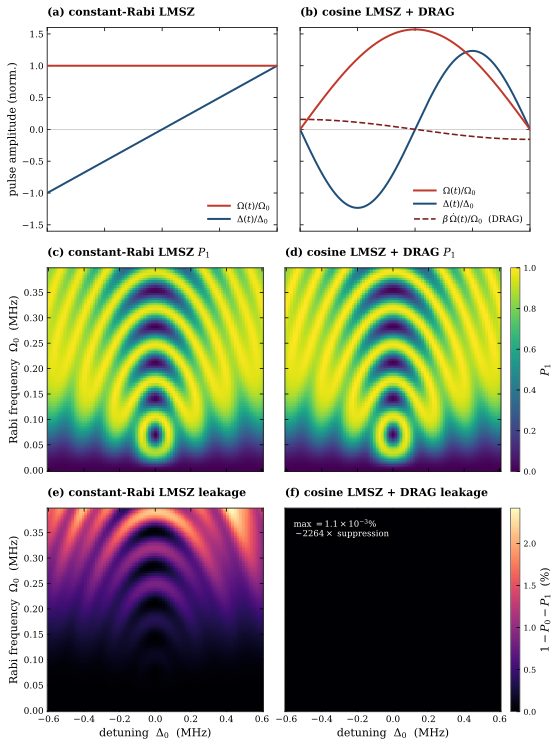

Max P_1: no DRAG = 0.9975, with DRAG = 1.0000
Max leak: no DRAG = 2.4199%, with DRAG = 0.001069%
Suppression (peak): 2264x


In [13]:
# ============================================================
# FIGURE
# ============================================================
fig = plt.figure(figsize=(8.6, 10.5))
gs  = GridSpec(3, 2, figure=fig,
               left=0.10, right=0.88, top=0.965, bottom=0.06,
               wspace=0.10, hspace=0.18)
ax_p_l = fig.add_subplot(gs[0, 0])
ax_p_d = fig.add_subplot(gs[0, 1])
ax_t_l = fig.add_subplot(gs[1, 0])
ax_t_d = fig.add_subplot(gs[1, 1])
ax_k_l = fig.add_subplot(gs[2, 0])
ax_k_d = fig.add_subplot(gs[2, 1])

# --- top row: pulse shapes (titles only on this row) ---
def plot_pulses(ax, Omega, Delta, drag=None, title=None, show_ylabel=True):
    ax.axhline(0, color='0.7', lw=0.6, zorder=1)
    ax.plot(x, Omega, color=C_RABI, lw=2.0, zorder=4, label=r'$\Omega(t)/\Omega_0$')
    ax.plot(x, Delta, color=C_DET,  lw=2.0, zorder=3, label=r'$\Delta(t)/\Delta_0$')
    if drag is not None:
        ax.plot(x, drag, color=C_DRAG, lw=1.6, ls='--', zorder=5,
                label=r'$\beta\,\dot\Omega(t)/\Omega_0$  (DRAG)')
    ax.set_xlim(-np.pi/2, np.pi/2)
    ax.set_ylim(-1.6, 1.6)
    ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax.set_xticklabels([r'$-\pi/2$', r'$-\pi/4$', '0', r'$\pi/4$', r'$\pi/2$'])
    ax.set_yticks([-1.5, -1, -0.5, 0, 0.5, 1, 1.5])
    ax.tick_params(axis='x', labelbottom=False)
    if show_ylabel:
        ax.set_ylabel(r'pulse amplitude (norm.)')
    else:
        ax.tick_params(axis='y', labelleft=False)
    ax.legend(loc='lower right', frameon=False, handlelength=2.4, borderaxespad=0.4)
    # if title: ax.set_title(title, pad=6)

plot_pulses(ax_p_l, Omega_const, Delta_lin,                    title=r'constant-Rabi LMSZ',      show_ylabel=True)
plot_pulses(ax_p_d, Omega_cos,   Delta_sin2x, drag=DRAG_quad,  title=r'cosine-Rabi LMSZ + DRAG', show_ylabel=False)

# --- middle row: transition probability (shared colorbar) ---
def plot_heatmap_prob(ax, data, show_ylabel=True, show_xlabel=False):
    im = ax.pcolormesh(d_range, A_range, data, vmin=0, vmax=1,
                       cmap=CMAP_P, shading='auto', rasterized=True)
    if show_xlabel:
        ax.set_xlabel(r'detuning  $\Delta_0$  (MHz)')
    else:
        ax.tick_params(axis='x', labelbottom=False)
    if show_ylabel:
        ax.set_ylabel(r'Rabi frequency  $\Omega_0$  (MHz)')
    else:
        ax.tick_params(axis='y', labelleft=False)
    return im

im_t_l = plot_heatmap_prob(ax_t_l, P1_l_map, show_ylabel=True,  show_xlabel=False)
im_t_d = plot_heatmap_prob(ax_t_d, P1_d_map, show_ylabel=False, show_xlabel=False)

cb_t = fig.colorbar(im_t_d, ax=[ax_t_l, ax_t_d], pad=0.02, fraction=0.040, aspect=22)
cb_t.set_label(r'$P_1$')
cb_t.ax.tick_params(labelsize=8)
cb_t.outline.set_linewidth(0.5)

# --- bottom row: leakage (shared color scale and shared colorbar) ---
def plot_heatmap_leak(ax, data, vmax, show_ylabel=True, show_xlabel=True):
    im = ax.pcolormesh(d_range, A_range, data, vmin=0, vmax=vmax,
                       cmap=CMAP_L, shading='auto', rasterized=True)
    if show_xlabel:
        ax.set_xlabel(r'detuning  $\Delta_0$  (MHz)')
    if show_ylabel:
        ax.set_ylabel(r'Rabi frequency  $\Omega_0$  (MHz)')
    else:
        ax.tick_params(axis='y', labelleft=False)
    return im

im_k_l = plot_heatmap_leak(ax_k_l, leak_l_pct, vmax=vmax_leak, show_ylabel=True,  show_xlabel=True)
im_k_d = plot_heatmap_leak(ax_k_d, leak_d_pct, vmax=vmax_leak, show_ylabel=False, show_xlabel=True)

cb_k = fig.colorbar(im_k_d, ax=[ax_k_l, ax_k_d], pad=0.02, fraction=0.040, aspect=22)
cb_k.set_label(r'$1-P_0-P_1$  (%)')
cb_k.ax.tick_params(labelsize=8)
cb_k.outline.set_linewidth(0.5)

# Annotation on (f) -- comment out if you don't want it
ax_k_d.text(0.04, 0.94,
            (r'max $= %.1f \times 10^{-3}$%%' % (1000 * leak_d_pct.max())) + '\n' +
            (r'$\sim\!%.0f\times$ suppression' % (leak_l.max() / max(leak_d.max(), 1e-30))),
            transform=ax_k_d.transAxes,
            fontsize=8.5, color='white', va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.35', fc='black', ec='none', alpha=0.55))

# --- panel labels (a)-(f) ---
for ax, lbl in zip([ax_p_l, ax_p_d, ax_t_l, ax_t_d, ax_k_l, ax_k_d],
                   ['(a) constant-Rabi LMSZ','(b) cosine LMSZ + DRAG',
                    r'(c) constant-Rabi LMSZ $P_1$', r'(d) cosine LMSZ + DRAG $P_1$',
                    r'(e) constant-Rabi LMSZ leakage', r'(f) cosine LMSZ + DRAG leakage']):
    ax.text(0, 1.10, lbl, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='left')

# --- save ---
fig.savefig('lmsz_drag_paper_figure.pdf', dpi=300, bbox_inches='tight')
fig.savefig('lmsz_drag_paper_figure.png', dpi=300, bbox_inches='tight')
plt.show()

# Headline numbers
print(f'Max P_1: no DRAG = {P1_l.max():.4f}, with DRAG = {P1_d.max():.4f}')
print(f'Max leak: no DRAG = {leak_l.max()*100:.4f}%, with DRAG = {leak_d.max()*100:.6f}%')
print(f'Suppression (peak): {leak_l.max()/max(leak_d.max(),1e-30):.0f}x')
